In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from scipy.stats import skew 
from scipy.stats import kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib.ticker import MultipleLocator
from sklearn.preprocessing import PowerTransformer
from matplotlib.ticker import FuncFormatter


In [2]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

In [3]:
df = pd.read_excel(fpath + '\\7.0_database_variables.xlsx', sheet_name = 'clean')

In [4]:
# Rename columns
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'week(1=free days)': 'weekday_type'})

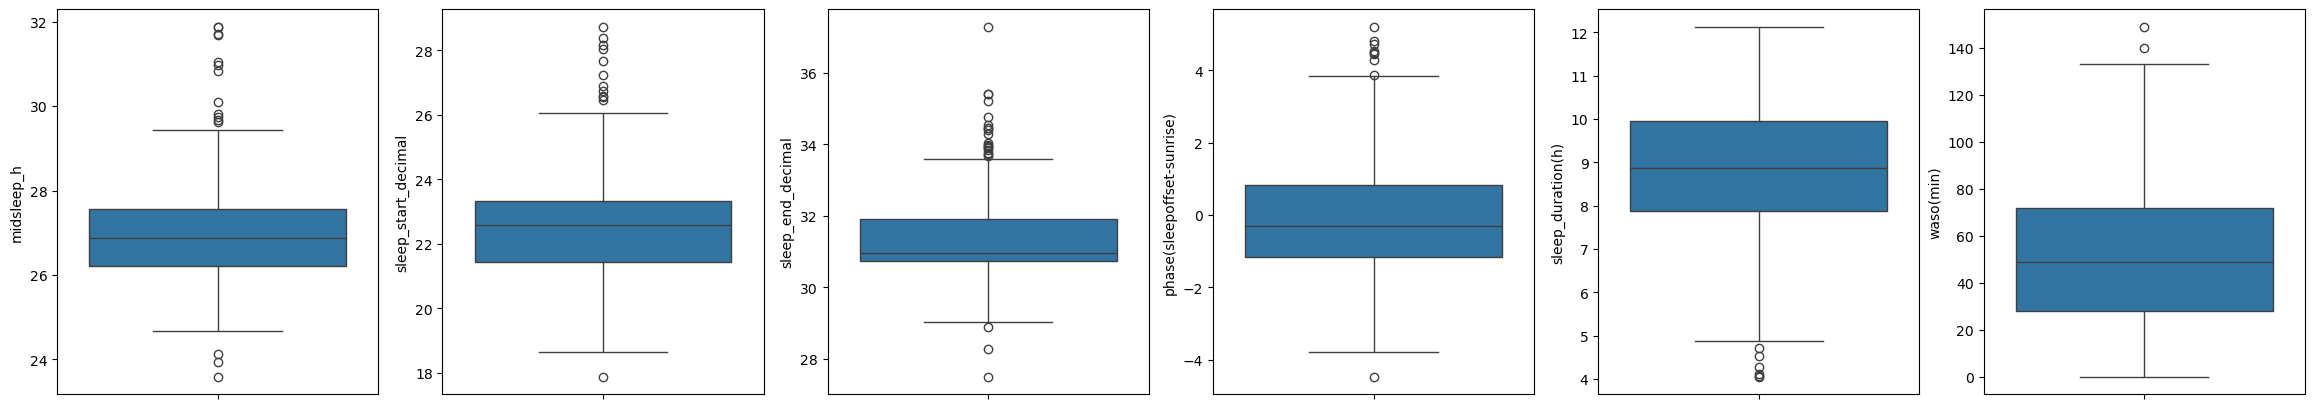

In [5]:
# box plot to verify the outliers
fig, ax = plt.subplots(1, 6, figsize=(29, 5))
sns.boxplot(data=df['midsleep_h'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)'], ax=ax[4])
sns.boxplot(data=df['waso(min)'], ax=ax[5])

plt.show()

In [6]:
# remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
df = df[(np.abs(stats.zscore(df['midsleep_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase(sleepoffset-sunrise)'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_duration(h)'])) < 3)]

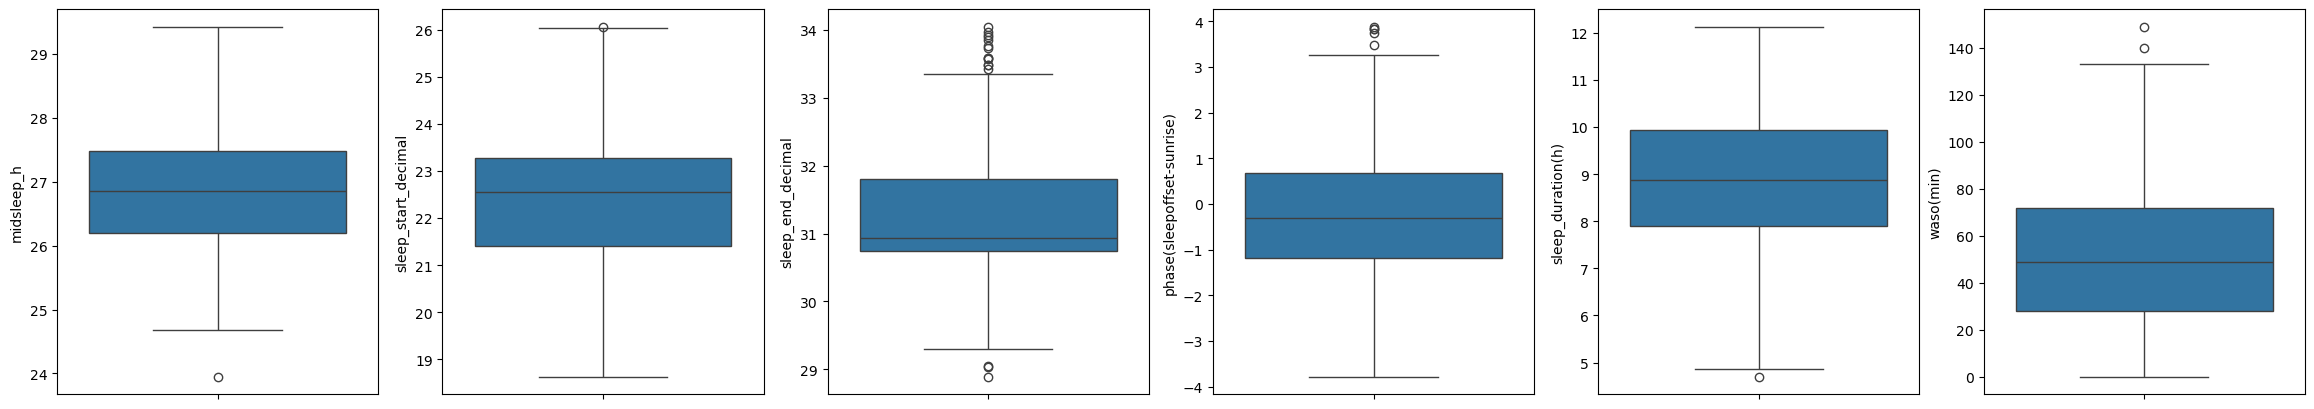

In [7]:
# box plot to verify the outliers
fig, ax = plt.subplots(1, 6, figsize=(29, 5))
sns.boxplot(data=df['midsleep_h'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)'], ax=ax[4])
sns.boxplot(data=df['waso(min)'], ax=ax[5])

plt.show()

In [8]:
# define the start date
start_date = pd.to_datetime('2022-02-01')

In [9]:
# function to count the week of the year from the start date 2022-02-01
def calculate_week_of_year(start_datetime): return (start_datetime - start_date).days // 7 + 5

# apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [10]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [11]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [12]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)'] = df['sleep_duration(h)'].astype(float)
df['sleep_duration_work_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'free days')

In [13]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [14]:
# create a new df for weekly jetlag analysis
data_jetlag_UTC = df 

In [15]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag_UTC = data_jetlag_UTC.groupby(['location', 'week_of_year', 'weekday_type'])['midsleep_h'].mean().unstack()

In [16]:
# calculate the jet lag for week and weekday
weekly_means_jetlag_UTC['jet lag'] = weekly_means_jetlag_UTC['free days'] - weekly_means_jetlag_UTC['work days']

In [17]:
# add a column with the location to the weekly_means_jetlag_UTC
weekly_means_jetlag_UTC['location'] = weekly_means_jetlag_UTC.index.get_level_values(0)

In [18]:
# rename columns
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})
df = df.rename(columns={'waso(min)': 'waso'})
df = df.rename(columns={'DST(0=ST)': 'DST_0'})

In [19]:
# dictionary with the season dates
seasons = {'Winter': [(12, 21), (3, 20)], 'Spring': [(3, 21), (6, 20)], 'Summer': [(6, 21), (9, 22)], 'Autumn': [(9, 23), (12, 20)]}

df['date'] = pd.to_datetime(df['date'])

In [20]:
# Function to get the season from the date
def get_season(date):
    month, day = date.month, date.day
    for season, ((start_month, start_day), (end_month, end_day)) in seasons.items():
        if (month == start_month and day >= start_day) or (month == end_month and day <= end_day):
            return season
        elif start_month < month < end_month:
            return season
    return 'Winter'  # for dates before 21st December and after 20th December

In [21]:
# Applying the function to create a season column
df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)
df.loc[:, 'season'] = df['date'].apply(get_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_42436\2634099026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_42436\2634099026.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)


In [22]:
# new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [23]:
# add a column with the photoperiod for the UK and ITA
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] 
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_42436\1608732957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']


In [24]:
# add the photoperiod column to the df_freedays
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_42436\2381324628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [25]:
# descpriptive statistics
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [26]:
# add the index as a column
all_descriptive['variable'] = all_descriptive.index 

In [27]:
#reset the index
all_descriptive = all_descriptive.reset_index(drop=True)

In [28]:
all_descriptive.to_excel(fpath + '\\all_descriptive.xlsx')

In [29]:
# descpriptive statistics for ITA
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()

In [30]:
descriptive_ita.to_excel(fpath + '\\descriptive_ita.xlsx')

In [31]:
# descpriptive statistics for UK
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()

In [32]:
descriptive_uk.to_excel(fpath + '\\descriptive_uk.xlsx')

In [33]:
# % of time spent in each location
count_location = df['location'].value_counts(normalize=True) * 100

In [34]:
count_location

location
ITA    58.211382
UK     41.788618
Name: proportion, dtype: float64

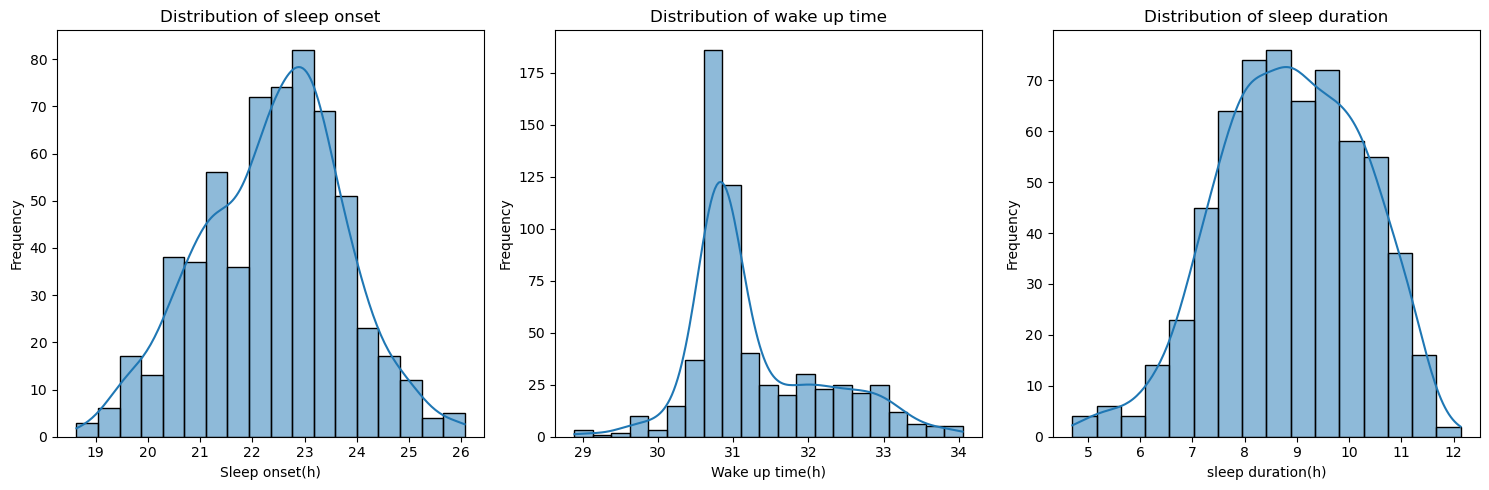

In [35]:
# distribution of the midpoint, sleep onset, sleep offset, and sleep duration
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal'].dropna(), kde=True)
plt.title("Distribution of wake up time")
plt.xlabel("Wake up time(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

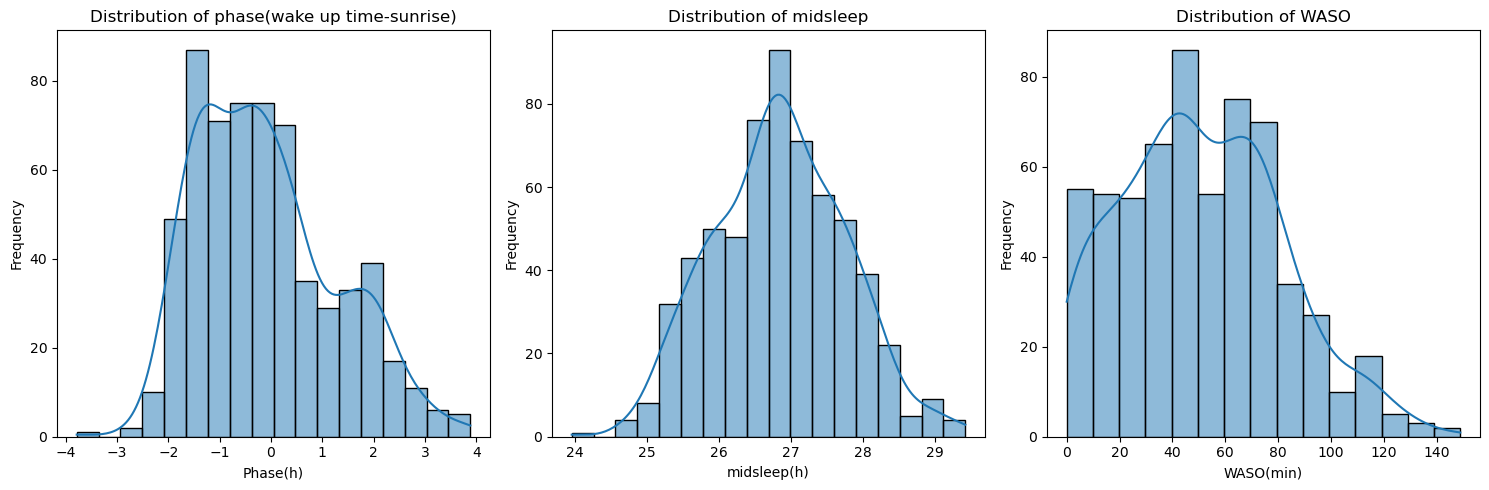

In [36]:
# distribution of phase and midpoint of sleep
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(wake up time-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='midsleep_h', kde=True)
plt.title("Distribution of midsleep")
plt.xlabel("midsleep(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='waso', kde=True)
plt.title("Distribution of WASO")
plt.xlabel("WASO(min)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

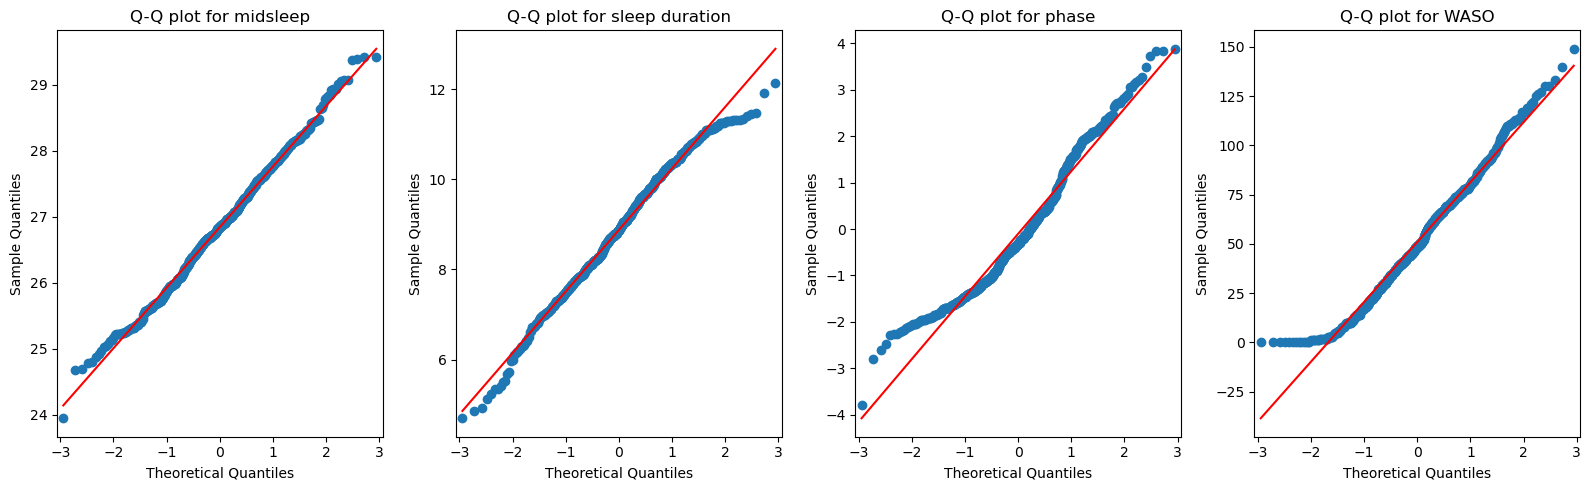

In [37]:
# Test normality by Q-Q plot
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

sm.qqplot(df['midsleep_h'].dropna(), line='s', ax=ax[0])
ax[0].set_title('Q-Q plot for midsleep')

sm.qqplot(df['sleep_duration'].dropna(), line='s', ax=ax[1])
ax[1].set_title('Q-Q plot for sleep duration')

sm.qqplot(df['phase'].dropna(), line='s', ax=ax[2])
ax[2].set_title('Q-Q plot for phase')

sm.qqplot(df['waso'].dropna(), line='s', ax=ax[3])
ax[3].set_title('Q-Q plot for WASO')

plt.tight_layout()
plt.show()


In [38]:
# test normality of the data using Shapiro-Wilk test 
# Null hipotesis(H0): data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration'])
shapiro_test_midsleep = stats.shapiro(df['midsleep_h'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal'])
shapiro_test_phase = stats.shapiro(df['phase'])
shapiro_test_waso = stats.shapiro(df['waso'].dropna())

In [39]:
shapiro_results_x = pd.DataFrame({
    'Variable': ['sleep_duration', 'midsleep_h', 'sleep_start_decimal', 'sleep_end_decimal', 'phase(sleepoffset-sunrise)', 'waso(min)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midsleep, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase, shapiro_test_waso]
})

In [40]:
shapiro_results_x

,Variable,Shapiro-Wilk test
0,sleep_duration,"(0.989206763568703, 0.00017064601689690861)"
1,midsleep_h,"(0.9962745448659057, 0.15838638324623877)"
2,sleep_start_decimal,"(0.993698963066055, 0.011421428491647475)"
3,sleep_end_decimal,"(0.8902901717096813, 1.668598709558079e-20)"
4,phase(sleepoffset-sunrise),"(0.9632591597148958, 2.8088616077879396e-11)"
5,waso(min),"(0.9801027193786289, 2.2101815715783285e-07)"


In [41]:
# test normality of the data using Shapiro-Wilk test for work days and free days (midpoint of sleep)
shapiro_test_midpoint_free = stats.shapiro(df[df['weekday_type'] == 'free days']['midsleep_h'])
shapiro_test_midpoint_work = stats.shapiro(df[df['weekday_type'] == 'work days']['midsleep_h'])

In [42]:
shapiro_results_free_work = pd.DataFrame({
    'Weekday type': ['free days', 'work days'],
    'Shapiro-Wilk test': [shapiro_test_midpoint_free, shapiro_test_midpoint_work]
})

In [43]:
shapiro_results_free_work

,Weekday type,Shapiro-Wilk test
0,free days,"(0.9856826245560115, 0.086648752785602)"
1,work days,"(0.9959226868935608, 0.3000383920660329)"


__General trends and variability in sleep patterns__

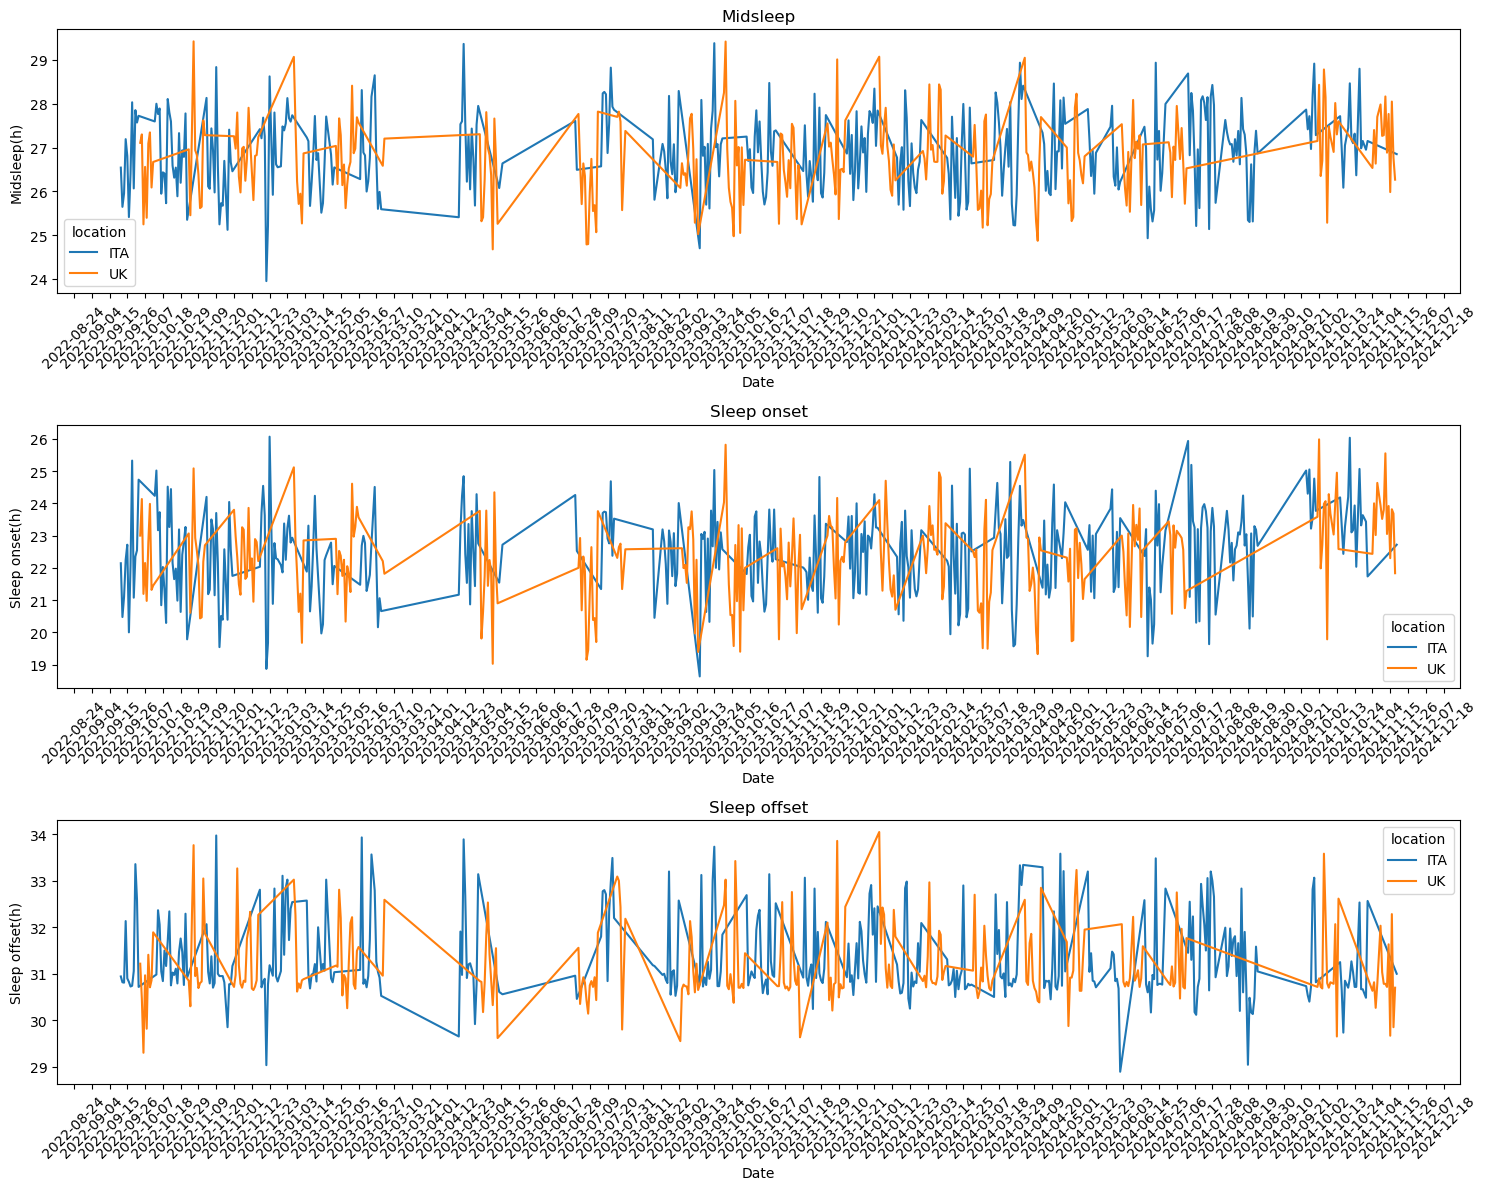

In [44]:
plt.figure(figsize=(15, 15))
plt.subplot(4, 1, 1)
sns.lineplot(data=df, x='date', y='midsleep_h', hue='location')
plt.title("Midsleep")
plt.xlabel("Date")
plt.ylabel("Midsleep(h)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.subplot(4, 1, 2)
sns.lineplot(data=df, x='date', y='sleep_start_decimal', hue='location')
plt.title("Sleep onset")
plt.xlabel("Date")
plt.ylabel("Sleep onset(h)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.subplot(4, 1, 3)
sns.lineplot(data=df, x='date', y='sleep_end_decimal', hue='location')
plt.title("Sleep offset")
plt.xlabel("Date")
plt.ylabel("Sleep offset(h)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.tight_layout()
plt.show()

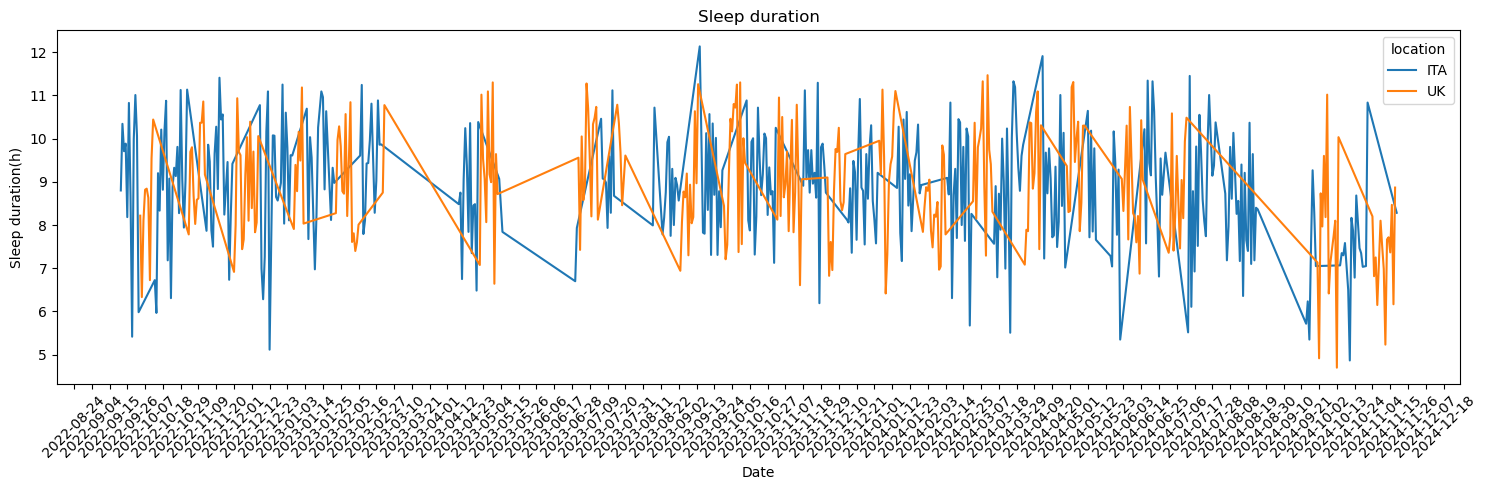

In [45]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x='date', y='sleep_duration', hue='location')
plt.title("Sleep duration")
plt.xlabel("Date")
plt.ylabel("Sleep duration(h)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.tight_layout()
plt.show()

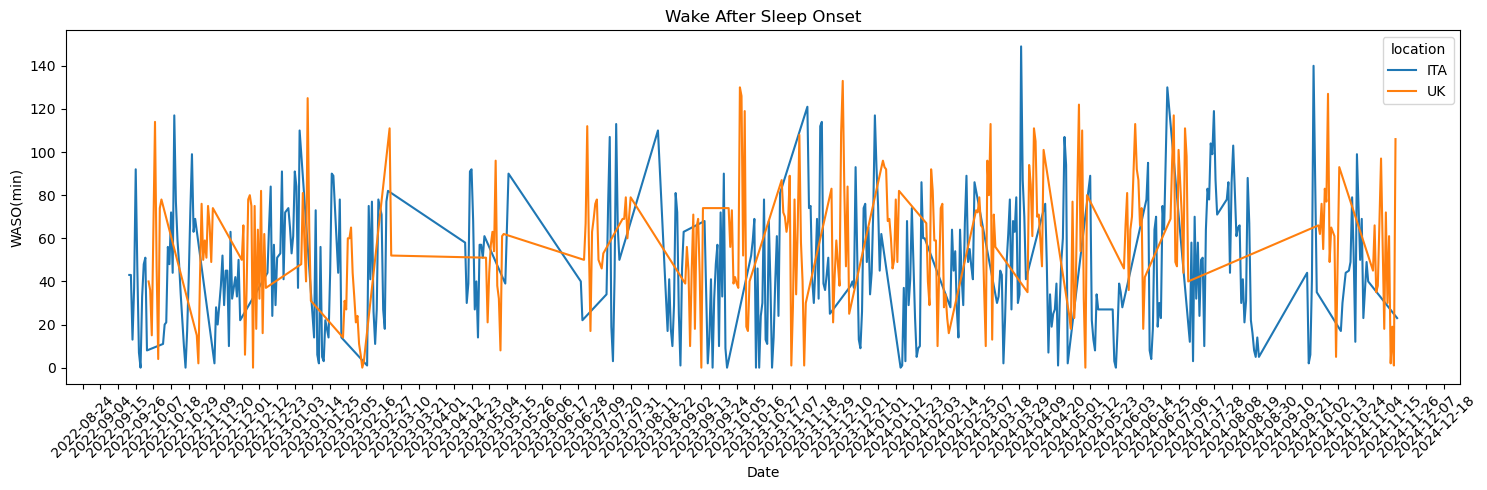

In [46]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x='date', y='waso', hue='location')
plt.title("Wake After Sleep Onset")
plt.xlabel("Date")
plt.ylabel("WASO(min)")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(MultipleLocator(11))

plt.tight_layout()
plt.show()

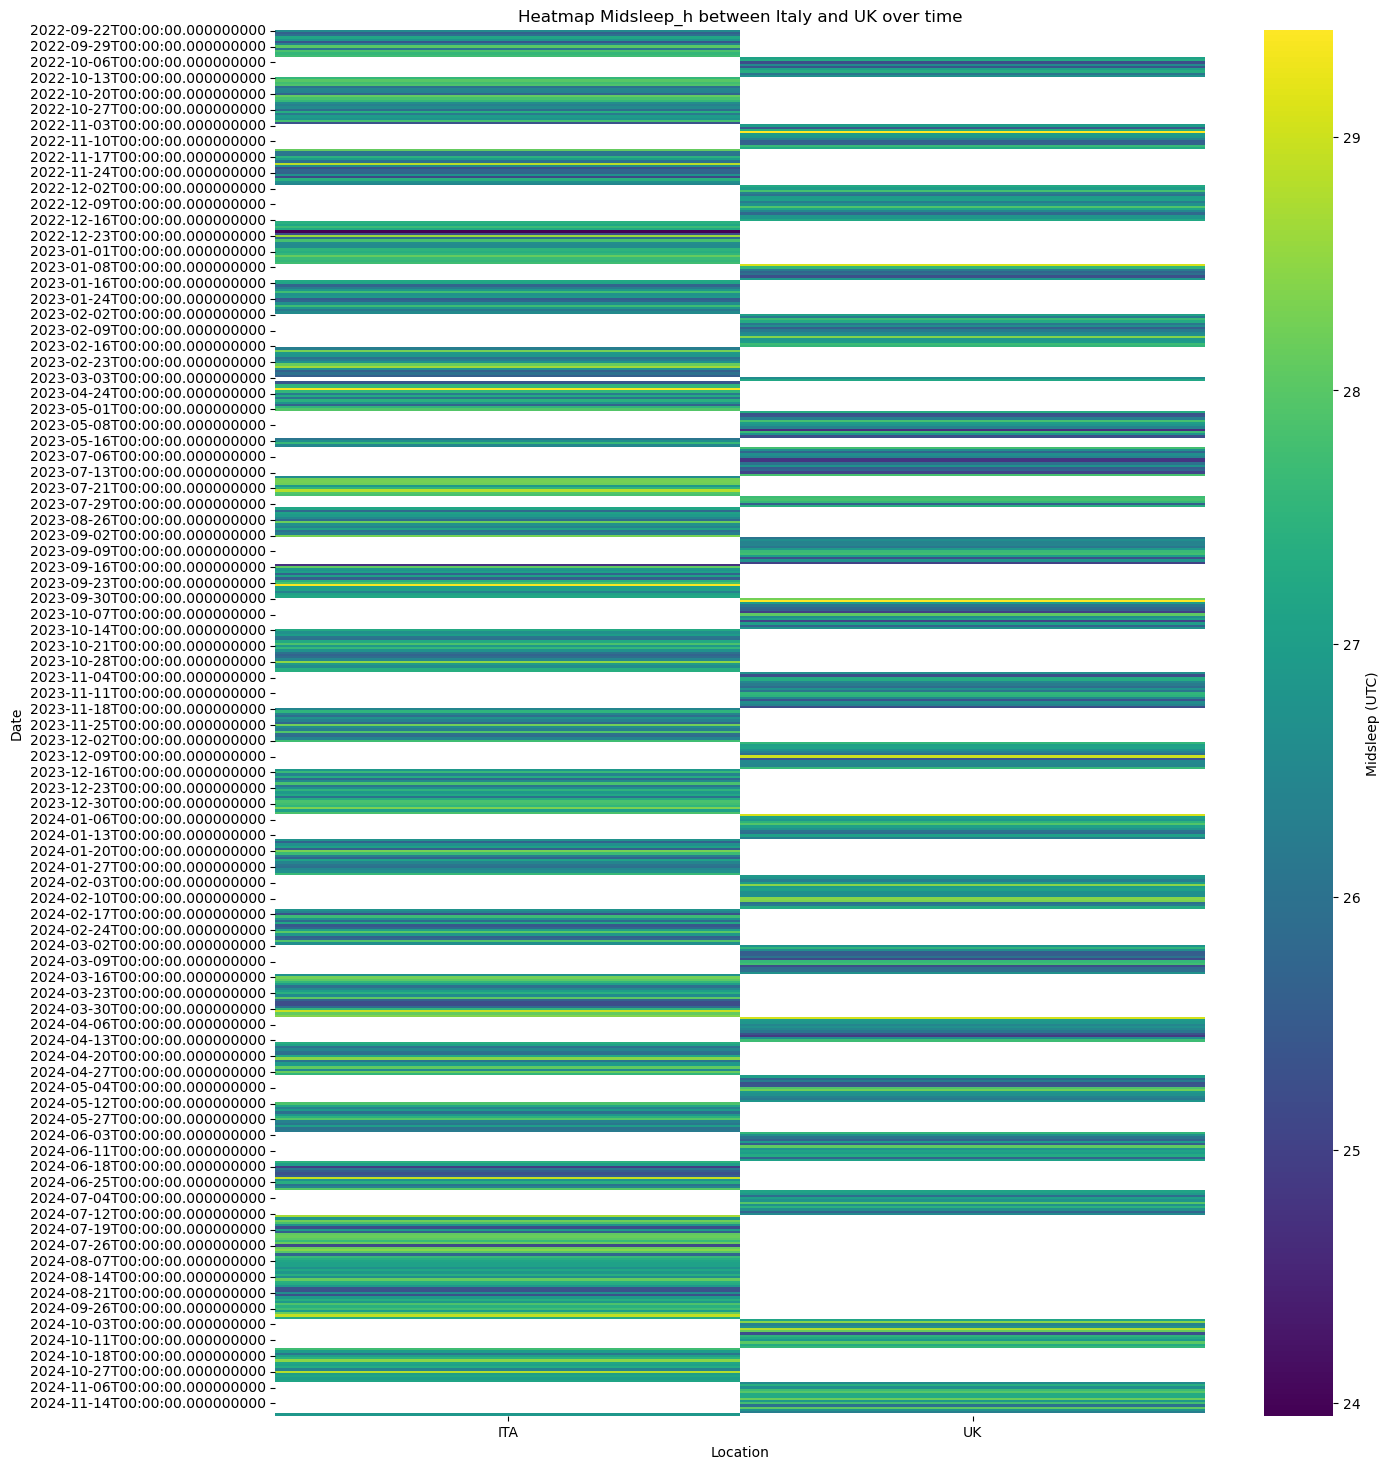

In [47]:
plt.figure(figsize=(15, 18))
df_pivot = df.pivot_table(index='date', columns='location', values='midsleep_h')
sns.heatmap(df_pivot, cmap="viridis", cbar_kws={'label': 'Midsleep (UTC)'})
plt.title('Heatmap Midsleep_h between Italy and UK over time')
plt.xlabel('Location')
plt.ylabel('Date')

plt.show()

__Sleep-wake pattern between Uk and Italy__

In [48]:
# descriptive statistics by location
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [49]:
# compare the variables between ITA and UK
ttest_midsleep_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midsleep_h'], df[df['location'] == 'UK']['midsleep_h'])
ttest_midsleep_workdays_loc = stats.ttest_ind(df_workdays[df_workdays['location'] == 'ITA']['midsleep_h'], df_workdays[df_workdays['location'] == 'UK']['midsleep_h'])
ttest_midsleep_freedays_loc = stats.ttest_ind(df_freedays[df_freedays['location'] == 'ITA']['midsleep_h'], df_freedays[df_freedays['location'] == 'UK']['midsleep_h'])
ttest_duration_loc = stats.ttest_ind(df[df['location'] == 'ITA']['sleep_duration'], df[df['location'] == 'UK']['sleep_duration'])

utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal'], df[df['location'] == 'UK']['sleep_start_decimal'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal'], df[df['location'] == 'UK']['sleep_end_decimal'])
utest_waso_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['waso'].dropna(), df[df['location'] == 'UK']['waso'].dropna())

In [50]:
# print the results
print('T test results by location')
print('Midsleep_all:', ttest_midsleep_all_loc)
print('Midsleep_work:', ttest_midsleep_workdays_loc)
print('Midsleep_free:', ttest_midsleep_freedays_loc)
print('Sleep_duration:', ttest_duration_loc)
print('U test results by location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Phase:', utest_phase_loc)
print('WASO:', utest_waso_loc)

T test results by location
Midsleep_all: TtestResult(statistic=2.4385238746771565, pvalue=0.015030226467868743, df=613.0)
Midsleep_work: TtestResult(statistic=3.0287269111073076, pvalue=0.0025980917969683688, df=447.0)
Midsleep_free: TtestResult(statistic=-0.07871595367124526, pvalue=0.9373545180669165, df=164.0)
Sleep_duration: TtestResult(statistic=-0.3657096008610571, pvalue=0.7147079436536141, df=613.0)
U test results by location
Sleep_onset: MannwhitneyuResult(statistic=50156.5, pvalue=0.05600672800929727)
Sleep_offset: MannwhitneyuResult(statistic=52992.0, pvalue=0.001300791514203901)
Phase: MannwhitneyuResult(statistic=25847.5, pvalue=1.7900333501485036e-20)
WASO: MannwhitneyuResult(statistic=35889.5, pvalue=9.15444505093321e-06)


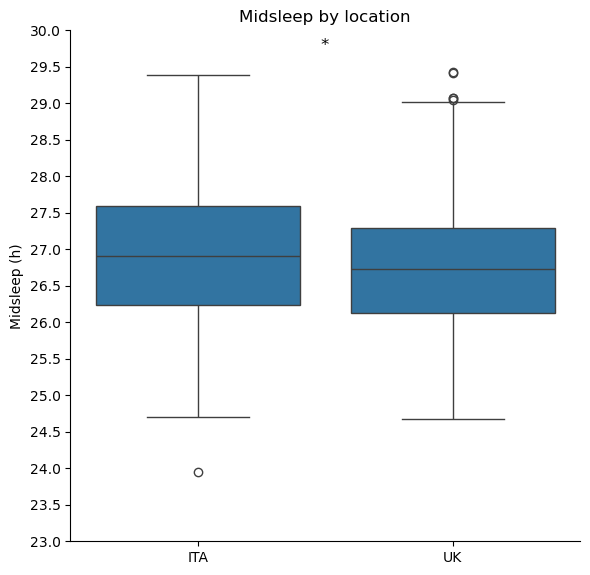

In [51]:
# plot the midpoint of sleep by location
plt.figure(figsize=(6, 6))
sns.boxplot(x='location', y='midsleep_h', data=df)
plt.title('Midsleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midsleep (h)')
plt.ylim(23, 30)
plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.5)) # gcd stands for 'get current axis'
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

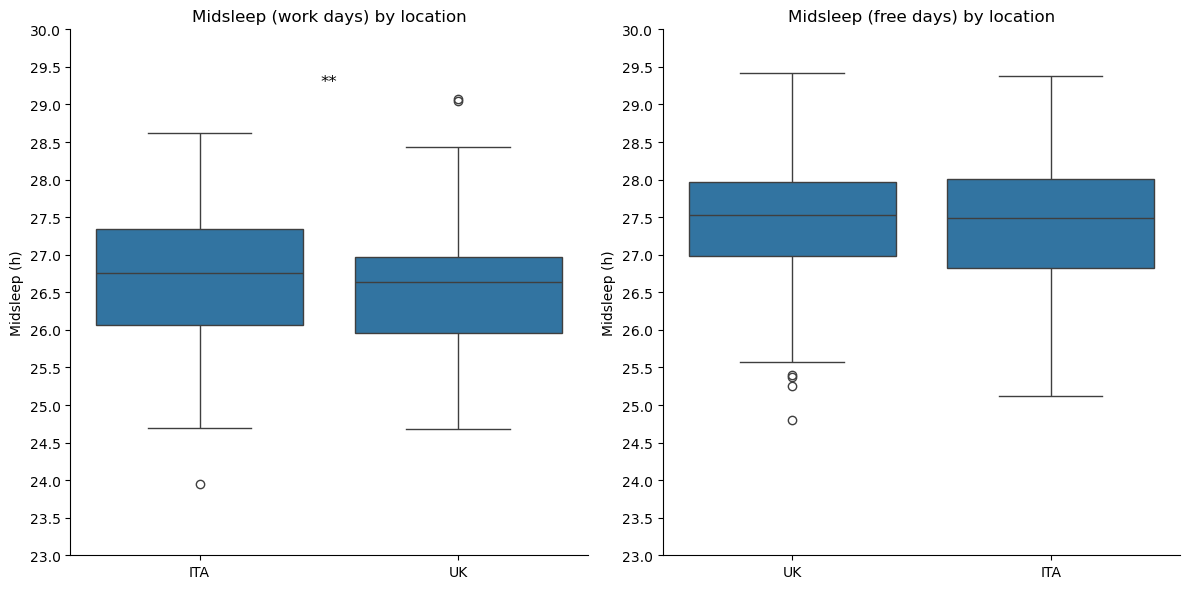

In [52]:
# plot the midpoint of sleep by location for free days and work days
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x='location', y='midsleep_h', data=df_workdays, ax=ax[0])
ax[0].set_title('Midsleep (work days) by location')
ax[0].set_ylabel('Midsleep (h)')
ax[0].set_xlabel('')
ax[0].yaxis.set_major_locator(MultipleLocator(0.5))
ax[0].set_ylim(23, 30)
ax[0].annotate('**', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of ** for the p-value < 0.001

sns.boxplot(x='location', y='midsleep_h', data=df_freedays, ax=ax[1])
ax[1].set_title('Midsleep (free days) by location')
ax[1].set_ylabel('Midsleep (h)')
ax[1].set_xlabel('')
ax[1].yaxis.set_major_locator(MultipleLocator(0.5))
ax[1].set_ylim(23, 30)
ax[1].annotate('', xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line of  for the p-value < 0.001
ax[1].invert_xaxis()
     
sns.despine()
plt.grid(False)
plt.gca().spines['bottom'].set_color('black') # set the color of the x-axis to black
plt.gca().spines['left'].set_color('black')
plt.tight_layout()
plt.show()

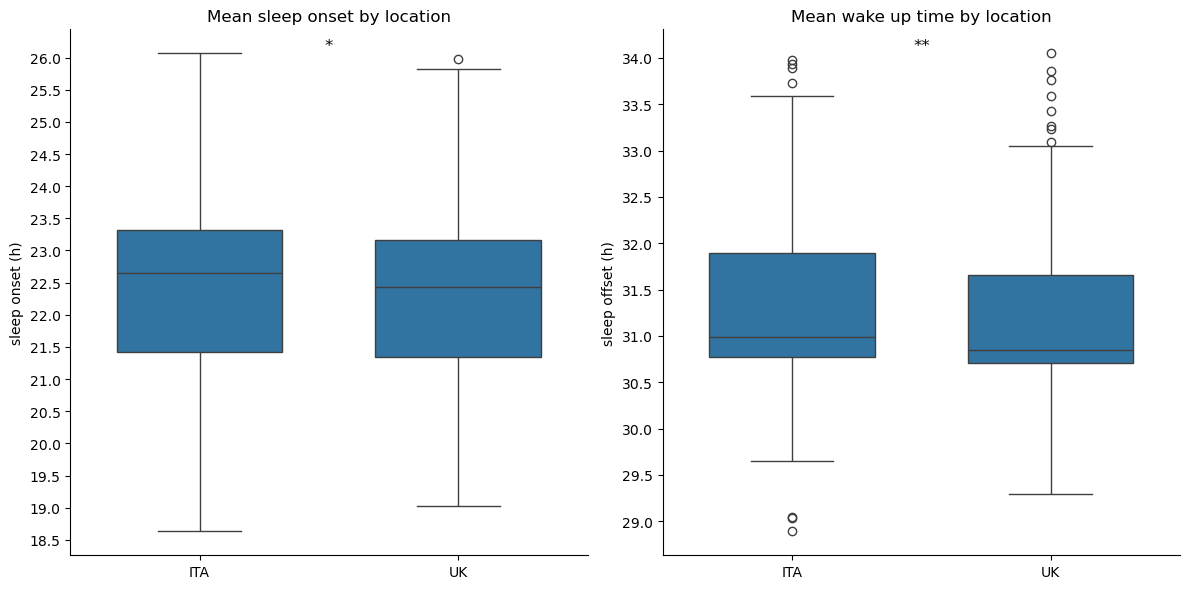

In [53]:
# plot the sleep onset and sleep offset by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h)')
plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal', data=df, gap=0.2)
plt.title('Mean wake up time by location')
plt.xlabel('')
plt.ylabel('sleep offset (h)')
plt.annotate('**', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

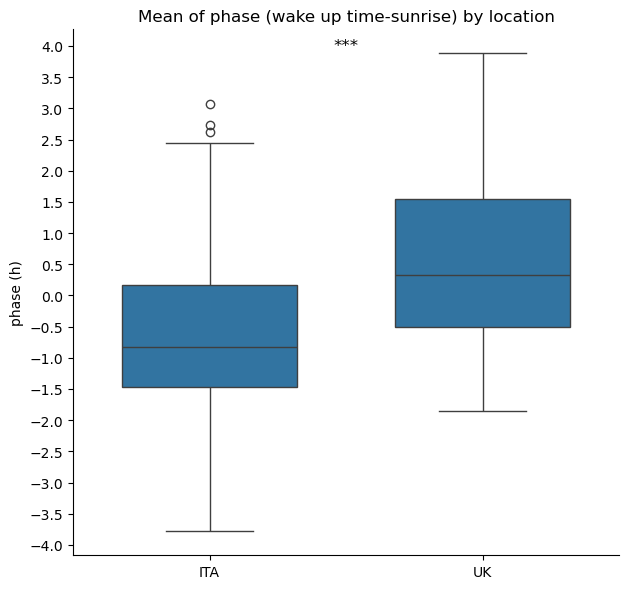

In [54]:
# plot the phase (sleep offset-sunrise) by location 
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='phase', data=df, gap=0.2)
plt.title('Mean of phase (wake up time-sunrise) by location')
plt.xlabel('')
plt.ylabel('phase (h)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

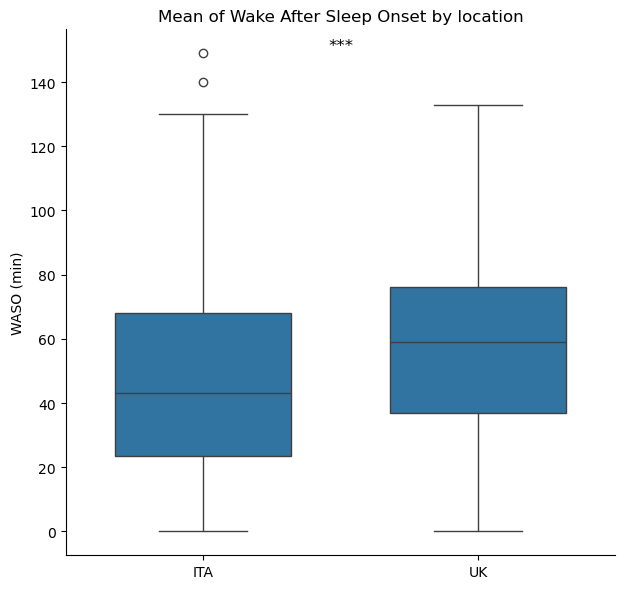

In [55]:
# plot the waso by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='waso', data=df, gap=0.2)
plt.title('Mean of Wake After Sleep Onset by location')
plt.xlabel('')
plt.ylabel('WASO (min)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
#plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

__Jet lag__

In [56]:
# drop the rows with missing values
jetlag_clean = weekly_means_jetlag_UTC['jet lag'].dropna()

In [57]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [58]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9765251139485136, pvalue=0.08235215015958525)


In [59]:
# test the difference in jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'ITA']['jet lag'].dropna(), 
                               weekly_means_jetlag_UTC[weekly_means_jetlag_UTC['location'] == 'UK']['jet lag'].dropna())

In [60]:
print('T test result for jet lag by location:')
print(ttest_jetlag)

T test result for jet lag by location:
TtestResult(statistic=-1.0478390045553172, pvalue=0.2973995718090164, df=94.0)


__Season and sleep-wake pattern__

In [61]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration']) 
df2 = df.dropna(subset=['phase'])
df3 = df.dropna(subset=['waso'])

In [62]:
anova_ols_midsleep_season = ols('midsleep_h ~ C(season)', data=df).fit() # generate and fit the regression model
anova_results_midsleep = sm.stats.anova_lm(anova_ols_midsleep_season, typ=3) # fit the ANOVA model and get the results

In [63]:
print('ANOVA Result for midsleep:')
print(anova_results_midsleep)

ANOVA Result for midsleep:
                  sum_sq     df              F   PR(>F)
Intercept  164182.813955    1.0  194685.135448  0.00000
C(season)       1.684923    3.0       0.665984  0.57317
Residual      515.271487  611.0            NaN      NaN


In [64]:
anova_sleep_duration_season = ols('sleep_duration ~ C(season)', data=df1).fit()
anova_results_sleep_duration = sm.stats.anova_lm(anova_sleep_duration_season, typ=2)

print('ANOVA Result for sleep duration:')
print(anova_results_sleep_duration)

ANOVA Result for sleep duration:
                sum_sq     df         F    PR(>F)
C(season)    20.340775    3.0  3.685481  0.011908
Residual   1124.069688  611.0       NaN       NaN


In [65]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df1['sleep_duration'], df1['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.3533  0.115 -0.0539 0.7604  False
Autumn Summer   0.2818 0.2529 -0.1115 0.6751  False
Autumn Winter   0.4305 0.0122  0.0685 0.7925   True
Spring Summer  -0.0714 0.9785 -0.5329   0.39  False
Spring Winter   0.0773 0.9681 -0.3578 0.5123  False
Summer Winter   0.1487 0.8008 -0.2734 0.5708  False
---------------------------------------------------


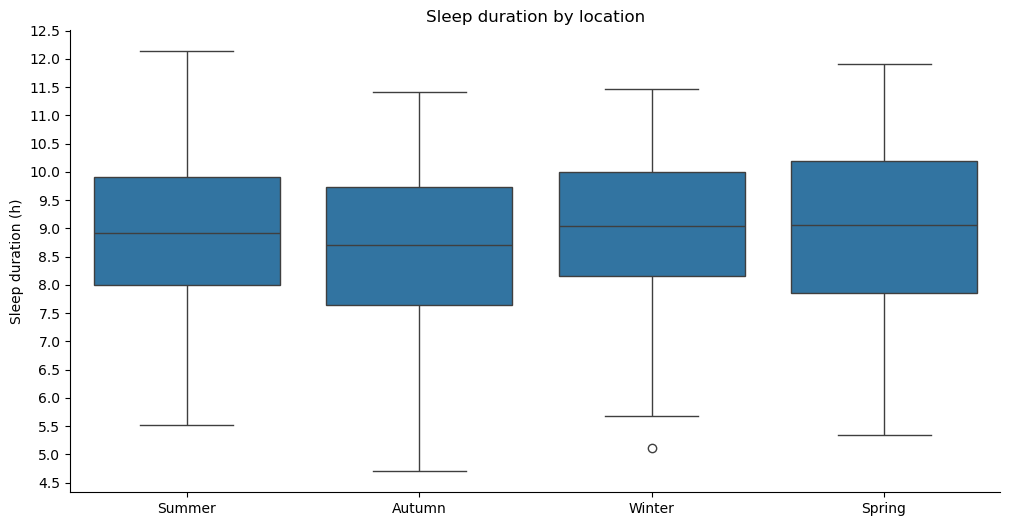

In [66]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration', data=df1)
plt.title('Sleep duration by location')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [67]:
# perform a Kruskal-Wallis test to compare the phase, sleep end and waso between the seasons
kw_phase_season = stats.kruskal(df2[df2['season'] == 'Winter']['phase'], df2[df2['season'] == 'Spring']['phase'], 
                                df2[df2['season'] == 'Summer']['phase'], df2[df2['season'] == 'Autumn']['phase'])

kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal'], df[df['season'] == 'Spring']['sleep_start_decimal'], 
                              df[df['season'] == 'Summer']['sleep_start_decimal'], df[df['season'] == 'Autumn']['sleep_start_decimal'])

kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal'], df[df['season'] == 'Spring']['sleep_end_decimal'], 
                              df[df['season'] == 'Summer']['sleep_end_decimal'], df[df['season'] == 'Autumn']['sleep_end_decimal'])

kw_waso_season = stats.kruskal(df3[df3['season'] == 'Winter']['waso'], df3[df3['season'] == 'Spring']['waso'], 
                               df3[df3['season'] == 'Summer']['waso'], df3[df3['season'] == 'Autumn']['waso'])

print('Kruskal-Wallis test results for phase:')
print(kw_phase_season)
print('Kruskal-Wallis test results for sleep start:')
print(kw_start_season)
print('Kruskal-Wallis test results for sleep end:')
print(kw_end_season)
print('Kruskal-Wallis test results for waso:')  
print(kw_waso_season)

Kruskal-Wallis test results for phase:
KruskalResult(statistic=191.70844785365287, pvalue=2.6094446815693496e-41)
Kruskal-Wallis test results for sleep start:
KruskalResult(statistic=5.616614850955755, pvalue=0.13182776482613484)
Kruskal-Wallis test results for sleep end:
KruskalResult(statistic=5.473777671034015, pvalue=0.14021544242788433)
Kruskal-Wallis test results for waso:
KruskalResult(statistic=1.9387158642456208, pvalue=0.5852233735859891)


In [68]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df2['phase'], df2['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.6416    0.0  1.3056  1.9777   True
Autumn Summer   1.5112    0.0  1.1865  1.8358   True
Autumn Winter   0.0171 0.9989 -0.2817  0.3159  False
Spring Summer  -0.1305 0.8139 -0.5113  0.2504  False
Spring Winter  -1.6246    0.0 -1.9837 -1.2655   True
Summer Winter  -1.4941    0.0 -1.8425 -1.1457   True
----------------------------------------------------


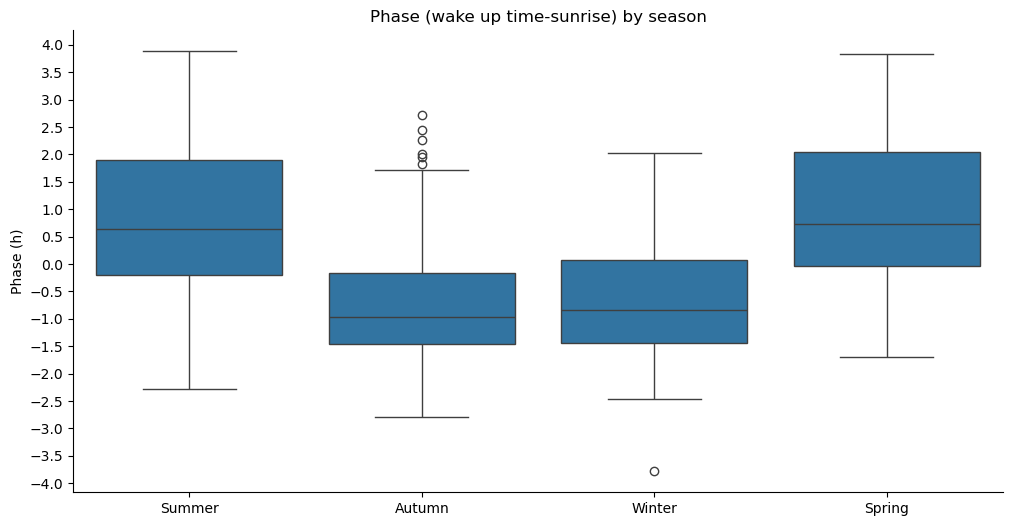

In [69]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__DST and sleep-wake pattern__

In [70]:
# t-test to compare the midpoint of sleep between DST and non-DST
ttest_midsleep_dst = stats.ttest_ind(df[df['DST_0'] == 0]['midsleep_h'], df[df['DST_0'] == 1]['midsleep_h'])
ttest_sleep_duration_dst = stats.ttest_ind(df1[df1['DST_0'] == 0]['sleep_duration'], df1[df1['DST_0'] == 1]['sleep_duration'])

utest_sleep_start_dst = stats.mannwhitneyu(df[df['DST_0'] == 0]['sleep_start_decimal'], df[df['DST_0'] == 1]['sleep_start_decimal'])
utest_sleep_end_dst = stats.mannwhitneyu(df[df['DST_0'] == 0]['sleep_end_decimal'], df[df['DST_0'] == 1]['sleep_end_decimal'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_0'] == 0]['phase'], df2[df2['DST_0'] == 1]['phase'])
utest_waso_dst = stats.mannwhitneyu(df3[df3['DST_0'] == 0]['waso'], df3[df3['DST_0'] == 1]['waso'])

In [71]:
print('T test result for the midsleep by DST:')
print(ttest_midsleep_dst)
print('T test result for the sleep duration by DST:')
print(ttest_sleep_duration_dst)
print('U test result for the sleep onset by DST:')
print(utest_sleep_start_dst)
print('U test result for the sleep offset by DST:')
print(utest_sleep_end_dst)
print('U test result for the phase by DST:')
print(utest_phase_dst)
print('U test result for the waso by DST:')
print(utest_waso_dst)

T test result for the midsleep by DST:
TtestResult(statistic=-0.9122417405232973, pvalue=0.36200008884475054, df=613.0)
T test result for the sleep duration by DST:
TtestResult(statistic=1.1971681276370192, pvalue=0.2317037795838161, df=613.0)
U test result for the sleep onset by DST:
MannwhitneyuResult(statistic=43607.0, pvalue=0.11154269695182177)
U test result for the sleep offset by DST:
MannwhitneyuResult(statistic=48233.0, pvalue=0.6087899026633519)
U test result for the phase by DST:
MannwhitneyuResult(statistic=27648.0, pvalue=8.89885662913842e-19)
U test result for the waso by DST:
MannwhitneyuResult(statistic=47096.0, pvalue=0.7887685495068093)


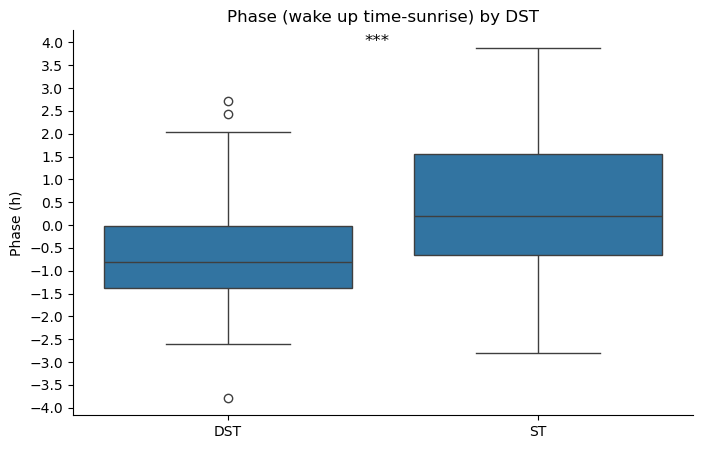

In [72]:
# phase (sleep offset - sunrise) by DST
plt.figure(figsize=(8, 5))
sns.boxplot(x='DST_0', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by DST')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['DST', 'ST'])
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('***', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__Photoperiod and sleep-wake pattern__

In [73]:
# correlation between sleep-wake variables and photoperiod
correlation_test1 = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
correlation_test2 = stats.pearsonr(df_workdays['midsleep_h_UTC'], df_workdays['photoperiod'])
correlation_test3 = stats.pearsonr(df_freedays['midsleep_h_UTC'], df_freedays['photoperiod'])
correlation_test4 = stats.pearsonr(df2['sleep_duration'], df2['photoperiod'])

# correlation between sleep-wake variables and photoperiod using Spearman's rank correlation
correlation_test5 = stats.spearmanr(df['sleep_start_decimal_UTC'], df['photoperiod'])
correlation_test6 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])
correlation_test7 = stats.spearmanr(df3['waso'], df3['photoperiod'])

In [74]:
# extract the coefficients and p-values from the correlation test results
correlation_coeff = [correlation_test1.statistic, correlation_test2.statistic, correlation_test3.statistic, 
                     correlation_test4.statistic, correlation_test5.statistic, correlation_test6.statistic,
                     correlation_test7.statistic]

p_values = [correlation_test1.pvalue, correlation_test2.pvalue, correlation_test3.pvalue, 
            correlation_test4.pvalue, correlation_test5.pvalue, correlation_test6.pvalue,
            correlation_test7.pvalue]

In [75]:
# create a DataFrame with the results
correlation_results = pd.DataFrame({
    'Variables': ['midsleep UTC vs photoperiod', 'midsleep (work) vs photoperiod', 'midsleep (free) vs photoperiod', 
                  'sleep duration UTC vs photoperiod', 'sleep onset UTC vs photoperiod', 'sleep offset UTC vs photoperiod', 'WASO(min) vs photoperiod'],
    'Coefficient': correlation_coeff,
    'P-value': p_values
})

correlation_results

,Variables,Coefficient,P-value
0,midsleep UTC vs photoperiod,-0.382518,7.299674e-23
1,midsleep (work) vs photoperiod,-0.390103,9.035010e-18
2,midsleep (free) vs photoperiod,-0.420489,1.696840e-08
3,sleep duration UTC vs photoperiod,0.017986,6.561944e-01
4,sleep onset UTC vs photoperiod,-0.303354,1.476573e-14
5,sleep offset UTC vs photoperiod,-0.395418,1.884514e-24
6,WASO(min) vs photoperiod,0.029734,4.631771e-01


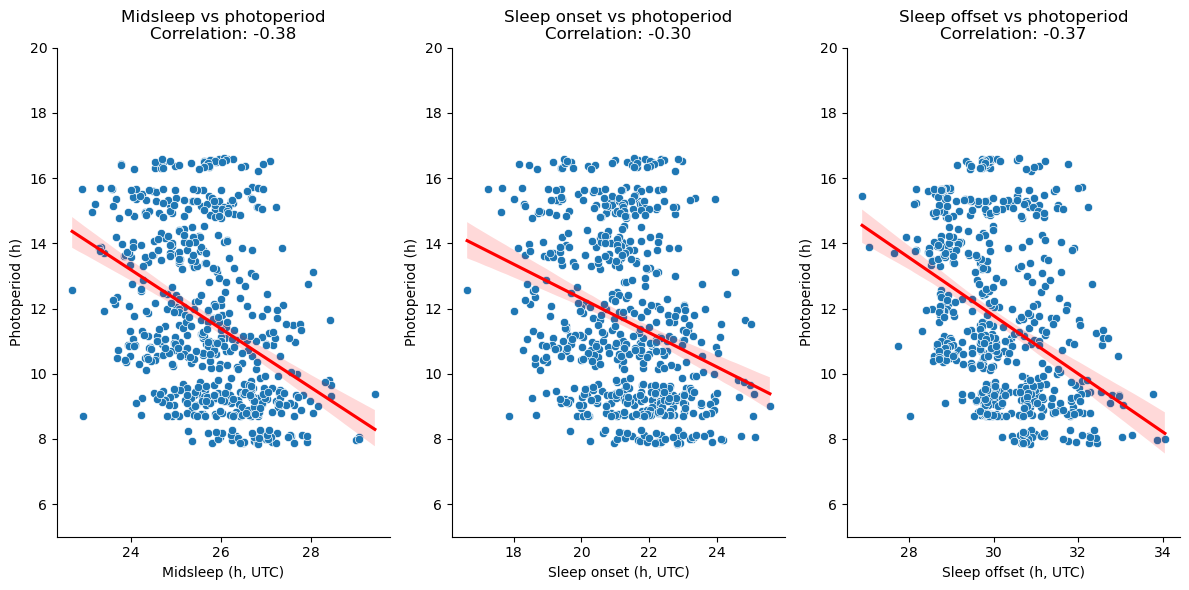

In [76]:
# plot the correlation between the midpoint of sleep and photoperiod, for all the data, work days and free days
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_all, _ = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
plt.title(f'Midsleep vs photoperiod\nCorrelation: {corr_all:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.subplot(1, 3, 2)
sns.scatterplot(x='sleep_start_decimal_UTC', y='photoperiod', data=df)
sns.regplot(x='sleep_start_decimal_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_free, _ = stats.pearsonr(df['sleep_start_decimal_UTC'], df['photoperiod'])
plt.title(f'Sleep onset vs photoperiod\nCorrelation: {corr_free:.2f}')
plt.xlabel('Sleep onset (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.subplot(1, 3, 3)
sns.scatterplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df)
sns.regplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_offset, _ = stats.pearsonr(df['sleep_end_decimal_UTC'], df['photoperiod'])
plt.title(f'Sleep offset vs photoperiod\nCorrelation: {corr_offset:.2f}')
plt.xlabel('Sleep offset (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.tight_layout()
plt.show()

__Weekly IV, IS and RA__

In [77]:
# load the datasets required for the analysis
weekly_values = pd.read_csv(fpath + '\\2.0_weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag_UTC

In [78]:
# split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [79]:
# convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [80]:
# merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [81]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag,location
0,15,2023-04-12 to 2023-04-18,NaN,0.024172,NaN,2023-04-12,2023-04-18,27.437500,26.821875,0.615625,ITA
1,32,2023-08-09 to 2023-08-15,NaN,0.048807,NaN,2023-08-09,2023-08-15,26.600000,27.093333,-0.493333,ITA
2,31,2024-07-31 to 2024-08-06,NaN,0.027033,0.949047,2024-07-31,2024-08-06,28.460417,26.690625,1.769792,ITA
3,33,2023-08-16 to 2023-08-22,NaN,0.053677,0.948446,2023-08-16,2023-08-22,27.397917,26.226667,1.171250,UK
4,9,2023-03-01 to 2023-03-07,NaN,0.040270,0.953698,2023-03-01,2023-03-07,27.406250,26.628333,0.777917,ITA


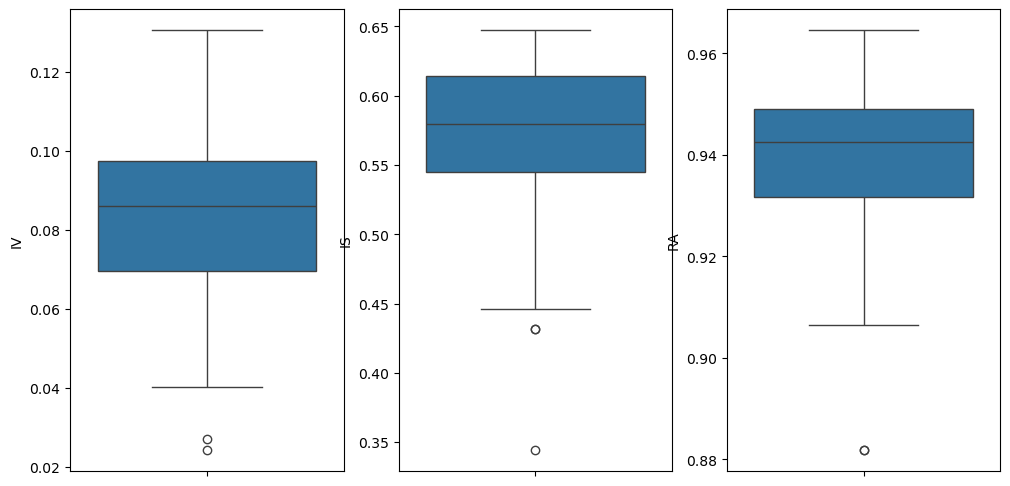

In [82]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [83]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()
summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       53.0  0.080466  0.022129  0.024172  0.067942  0.082638  0.093785   
UK        36.0  0.088307  0.017596  0.053677  0.075609  0.087177  0.098561   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  48.0  0.574327  ...  0.614767  0.647358  50.0  0.940170   
UK        0.130562  34.0  0.567904  ...  0.613489  0.645810  34.0  0.937674   

                                                                     
              std       min       25%       50%       75%       max  
location                                                             
ITA       0.01533  0.881815  0.931972  0.942574  0.950680  0.964584  
UK        0.01699  0.881815  0.930985  0.942574  0.947245  0.962952  

[2 rows x 24 columns]

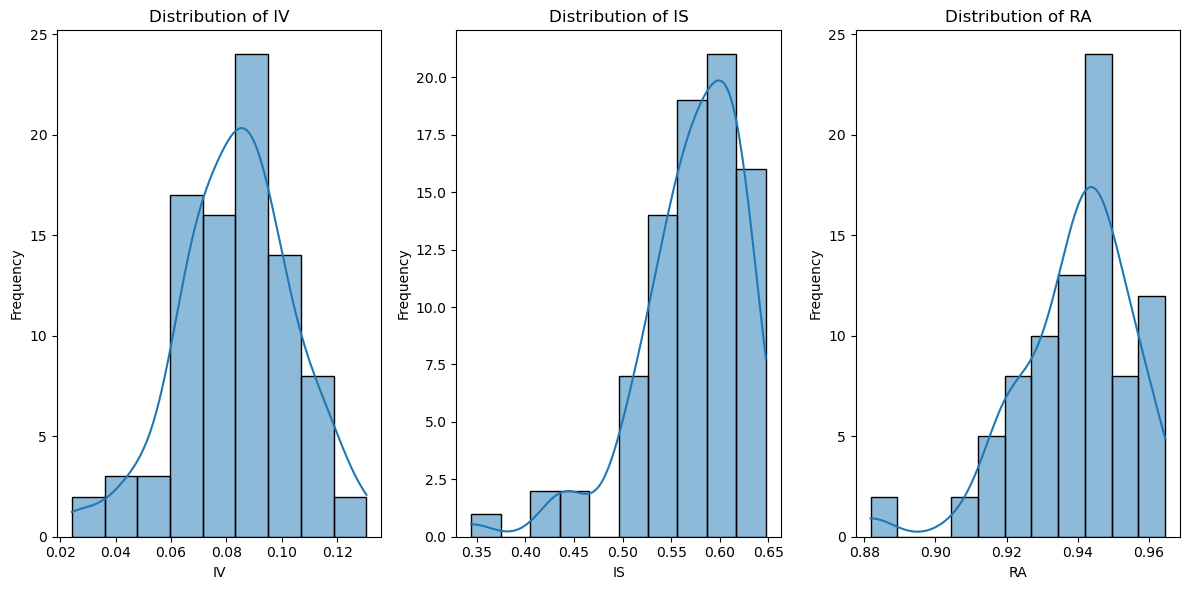

In [84]:
# distribution of IV, IS, and RA
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [85]:
# compare the variables between ITA and UK
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [86]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_utest)
print('Test results for RA by location:', ra_utest)

Test results for IV by location: TtestResult(statistic=-1.7772445658632352, pvalue=0.07902284498496115, df=87.0)
Test results for IS by location: MannwhitneyuResult(statistic=869.5, pvalue=0.6178431739272754)
Test results for RA by location: MannwhitneyuResult(statistic=916.5, pvalue=0.5474926482394891)


------------------------

__Sleep-wake patterns over time__

In [87]:
# new column with the day after flight category 1-3 days and >3 days
df['day_after_flight_category_simple'] = pd.cut(df['day_after_flight'], bins=[0, 1, 2, 3, 4, max(df['day_after_flight'])], labels=['1 day', '2 days', '3 days', '4 days', '>5 days'])
df['day_after_flight_category_simple2'] = pd.cut(df['day_after_flight'], bins=[0, 1, 2, 3, max(df['day_after_flight'])], labels=['1 day', '2 days', '3 days', '>3 days'])

df2.loc[:, 'day_after_flight_category_simple'] = pd.cut(df2['day_after_flight'], bins=[0, 1, 2, 3, 4, max(df2['day_after_flight'])], labels=['1 day', '2 days', '3 days', '4 days', '>5 days'])
df2.loc[:, 'day_after_flight_category_simple2'] = pd.cut(df2['day_after_flight'], bins=[0, 1, 2, 3, max(df2['day_after_flight'])], labels=['1 day', '2 days', '3 days', '>3 days'])

df3.loc[:, 'day_after_flight_category_simple'] = pd.cut(df3['day_after_flight'], bins=[0, 1, 2, 3, 4, max(df3['day_after_flight'])], labels=['1 day', '2 days', '3 days', '4 days', '>5 days'])
df3.loc[:, 'day_after_flight_category_simple2'] = pd.cut(df3['day_after_flight'], bins=[0, 1, 2, 3, max(df3['day_after_flight'])], labels=['1 day', '2 days', '3 days', '>3 days'])

#df2['day_after_flight_category_simple'] = pd.cut(df2['day_after_flight'], bins=[0, 4, max(df2['day_after_flight'])], labels=['1-4 days', '>4 days'])
#df3['day_after_flight_category_simple'] = pd.cut(df3['day_after_flight'], bins=[0, 4, max(df3['day_after_flight'])], labels=['1-4 days', '>4 days'])

C:\Users\gg00642\AppData\Local\Temp\ipykernel_42436\1183436115.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.loc[:, 'day_after_flight_category_simple'] = pd.cut(df3['day_after_flight'], bins=[0, 1, 2, 3, 4, max(df3['day_after_flight'])], labels=['1 day', '2 days', '3 days', '4 days', '>5 days'])
C:\Users\gg00642\AppData\Local\Temp\ipykernel_42436\1183436115.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.loc[:, 'day_after_flight_category_simple2'] = pd.cut(df3['day_after_flight'], bins=[0,

_Sleep onset_

In [88]:
model1 = smf.mixedlm('sleep_start_decimal ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000)
print(model1.summary())


              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sleep_start_decimal
No. Observations: 615     Method:             REML               
No. Groups:       45      Scale:              1.7211             
Min. group size:  1       Log-Likelihood:     -1057.5137         
Max. group size:  46      Converged:          Yes                
Mean group size:  13.7                                           
------------------------------------------------------------------
                  Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept         22.324     0.104  214.814  0.000  22.120  22.527
day_after_flight   0.006     0.009    0.707  0.480  -0.011   0.024
Group Var          0.107     0.040                                



In [89]:
model2 = smf.mixedlm('sleep_start_decimal ~ day_after_flight + location + location*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                   Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    sleep_start_decimal
No. Observations:     615        Method:                REML               
No. Groups:           45         Scale:                 1.7087             
Min. group size:      1          Log-Likelihood:        -1058.7714         
Max. group size:      46         Converged:             Yes                
Mean group size:      13.7                                                 
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       22.339    0.136 163.689 0.000 22.072 22.607
location[T.UK]                   0.163    0.227   0.717 0.473 -0.282  0.607
day_after_flight                 0.013    0.010   1.310 0.190 -0.006  0.032
location[T.UK]:day_after_flight

In [90]:
model3 = smf.mixedlm('sleep_start_decimal ~ C(day_after_flight_category_simple, Treatment(reference=">5 days"))', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model3.summary())

                                          Mixed Linear Model Regression Results
Model:                                MixedLM                   Dependent Variable:                   sleep_start_decimal
No. Observations:                     615                       Method:                               REML               
No. Groups:                           45                        Scale:                                1.6986             
Min. group size:                      1                         Log-Likelihood:                       -1052.4439         
Max. group size:                      46                        Converged:                            Yes                
Mean group size:                      13.7                                                                               
-------------------------------------------------------------------------------------------------------------------------
                                                                  

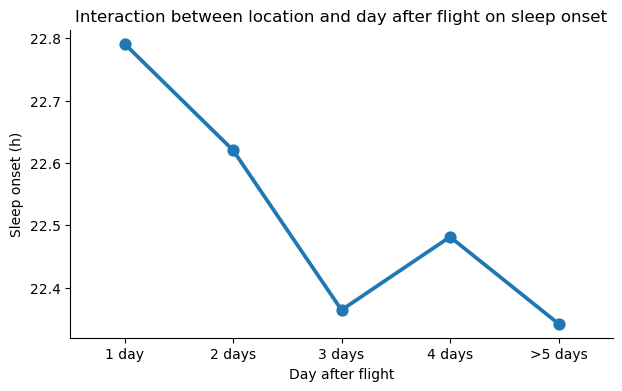

In [91]:
#plot the interaction between location and day after flight
plt.figure(figsize=(7, 4))
sns.pointplot(x='day_after_flight_category_simple', y='sleep_start_decimal', data=df, errorbar=None)
plt.title('Interaction between location and day after flight on sleep onset')
plt.xlabel('Day after flight')
plt.ylabel('Sleep onset (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.show()

In [92]:
model4 = smf.mixedlm('sleep_start_decimal ~ C(location) + C(day_after_flight_category_simple, Treatment(reference=">5 days")) + C(location)*C(day_after_flight_category_simple, Treatment(reference=">5 days"))', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model4.summary())

                                                   Mixed Linear Model Regression Results
Model:                                      MixedLM                         Dependent Variable:                         sleep_start_decimal
No. Observations:                           615                             Method:                                     REML               
No. Groups:                                 45                              Scale:                                      1.6742             
Min. group size:                            1                               Log-Likelihood:                             -1046.7149         
Max. group size:                            46                              Converged:                                  Yes                
Mean group size:                            13.7                                                                                           
-----------------------------------------------------------------------

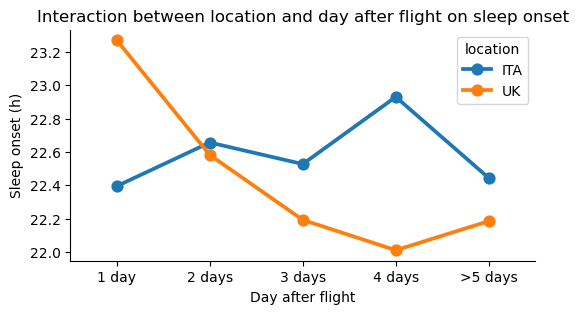

In [93]:
#plot the interaction between location and day after flight
plt.figure(figsize=(6, 3))
sns.pointplot(x='day_after_flight_category_simple', y='sleep_start_decimal', hue='location', data=df, errorbar=None)
plt.title('Interaction between location and day after flight on sleep onset')
plt.xlabel('Day after flight')
plt.ylabel('Sleep onset (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.show()

In [94]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5 = smf.mixedlm('sleep_start_decimal ~ C(location) + photoperiod + C(location)*photoperiod + day_after_flight + C(location)*day_after_flight',
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

                    Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     sleep_start_decimal
No. Observations:     615         Method:                 REML               
No. Groups:           45          Scale:                  1.7107             
Min. group size:      1           Log-Likelihood:         -1060.8927         
Max. group size:      46          Converged:              Yes                
Mean group size:      13.7                                                   
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          21.765    0.492 44.222 0.000 20.800 22.729
C(location)[T.UK]                   1.562    0.669  2.334 0.020  0.250  2.873
photoperiod                         0.048    0.040  1.202 0.229 -0.030  0.125
C(loca

In [95]:
coef_onset = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_onset

,coef,p-value,0.025,0.975
Intercept,21.764721,0.000000,20.800090,22.729351
C(location)[T.UK],1.561644,0.019617,0.250033,2.873255
photoperiod,0.047511,0.229490,-0.029981,0.125004
C(location)[T.UK]:photoperiod,-0.117790,0.026187,-0.221622,-0.013958
day_after_flight,0.014970,0.124172,-0.004113,0.034054
C(location)[T.UK]:day_after_flight,-0.048466,0.033928,-0.093255,-0.003678
Group Var,0.053495,0.074605,-0.005313,0.112304


In [96]:
#drop non significant variables
coef_onset = coef_onset.drop('Intercept')
coef_onset = coef_onset.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_42436\1928092645.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location [T.UK]', 'Photoperiod', 'Location [T.UK]*Photoperiod','Days after flight', 'Location [T.UK]*Days after flight'], fontsize=9)


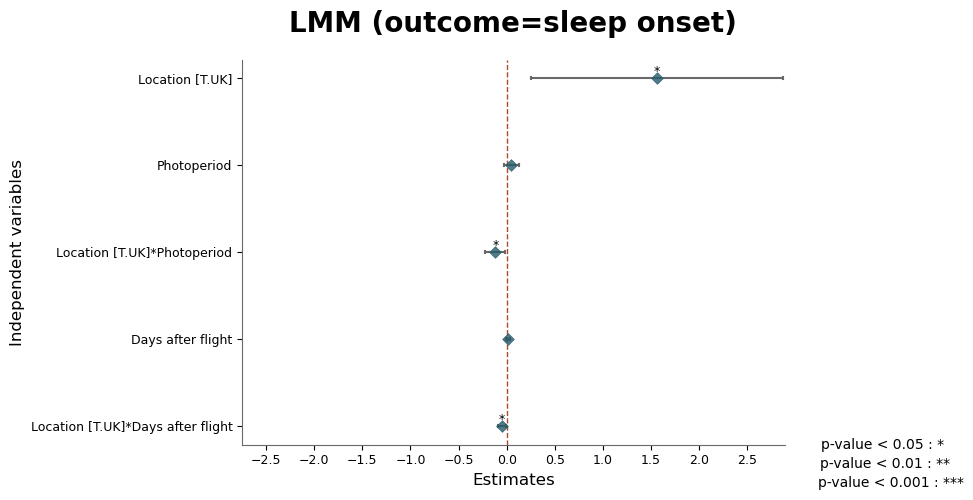

In [97]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_onset.index, data=coef_onset, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_onset.shape[0]):
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.975'].iloc[i], coef_onset['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_onset.shape[0]):
    if coef_onset['p-value'].iloc[i] < 0.001:
        plt.text(coef_onset['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.01:
        plt.text(coef_onset['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.055:
        plt.text(coef_onset['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=sleep onset)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.89)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location [T.UK]', 'Photoperiod', 'Location [T.UK]*Photoperiod','Days after flight', 'Location [T.UK]*Days after flight'], fontsize=9)

plt.show()

<Figure size 800x600 with 0 Axes>

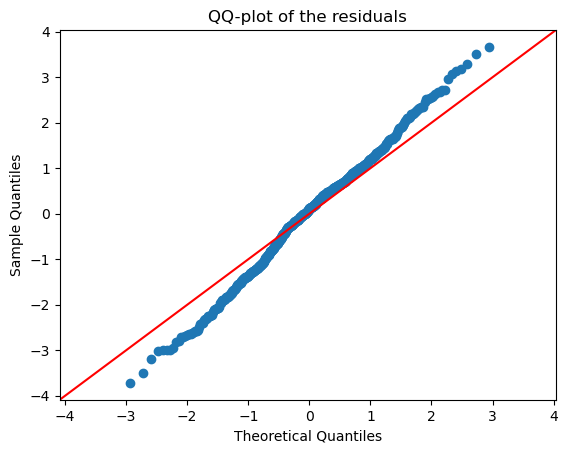

In [98]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [99]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [100]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 3.233043839859135, p-value: 0.6641071851437186
The residuals are homoscedastic (fail to reject H0).


In [101]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.9207557339921075


In [102]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

In [173]:
#extract from df sunrise and sunset times for both the UK and Italy and create a new dataframe df_daylight
df_daylight = pd.read_excel(fpath + '\\2.0_database_variables.xlsx', sheet_name='Sheet1')
#df_daylight = df[['start_datetime', 'date', 'location', 'sunrise (uk), hours', 'sunset (uk), hours', 'sunrise (ita), hours', 'sunset (ita), hours']]

In [117]:
#df_daylight['location'] = df_daylight['location'].map({'ITA': 0, 'UK': 1})

In [105]:
#df_daylight['month'] = df_daylight['date'].dt.month

In [106]:
#df_daylight['year'] = df_daylight['date'].dt.year

In [167]:
# Function to convert hours to hh:mm format
def hours_to_hhmm(x, pos):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return f'{hours:02d}:{minutes:02d}'

In [174]:
def adjust_value(row):
    timeshift = row['DST(0=ST)']
    
    if timeshift == 0:
                return row['sunrise (uk), hours'] + 1, row['sunset (uk), hours'] + 1, row['sunrise (ita), hours'] + 2, row['sunset (ita), hours'] + 2
    elif timeshift == 1:
                return row['sunrise (uk), hours'] - 0, row['sunset (uk), hours'] - 0, row['sunrise (ita), hours'] + 1, row['sunset (ita), hours'] + 1
    
    return row['sunrise (uk), hours'], row['sunset (uk), hours'], row['sunrise (ita), hours'], row['sunset (ita), hours']

##df_daylight['start_datetime'] = pd.to_datetime(df_daylight['start_datetime'])  # Convert 'start_time' column to datetime

df_daylight[['sunrise (uk), hours_adjust', 'sunset (uk), hours_adjust', 'sunrise (ita), hours_adjust', 'sunset (ita), hours_adjust']] = df_daylight.apply(adjust_value, axis=1, result_type='expand')

print(df_daylight)

          date sunrise (uk)  sunrise (uk), hours sunset (uk)  \
0   2022-12-19     08:03:00             8.050000    15:52:00   
1   2022-12-21     08:04:00             8.066667    15:53:00   
2   2022-12-23     08:05:00             8.083333    15:54:00   
3   2023-12-19     08:03:00             8.050000    15:52:00   
4   2023-12-20     08:04:00             8.066667    15:53:00   
..         ...          ...                  ...         ...   
835 2024-06-24     03:44:00             3.733333    20:22:00   
836 2023-06-21     03:43:00             3.716667    20:22:00   
837 2023-06-22     03:43:00             3.716667    20:22:00   
838 2024-06-21     03:43:00             3.716667    20:22:00   
839 2024-06-22     03:43:00             3.716667    20:22:00   

     sunset (uk), hours sunrise (ita)  sunrise (ita), hours sunset (ita)  \
0             15.866667      07:48:00              7.800000     16:31:00   
1             15.883333      07:49:00              7.816667     16:32:00   
2  

In [175]:
# Drop NaN values
df_daylight_clean = df_daylight.dropna(subset=['location(ita_0)'])

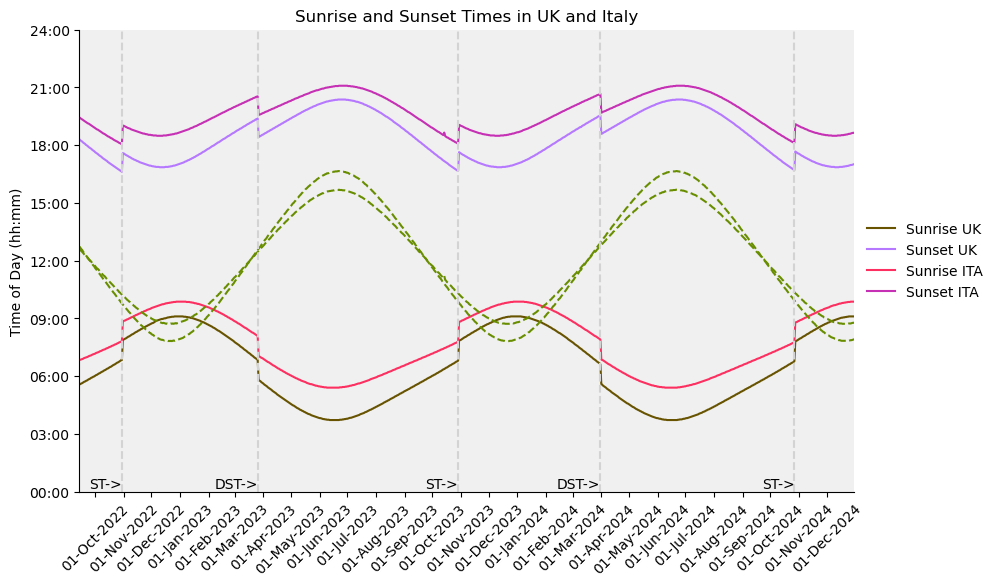

In [182]:
# Plot with cleaned data
plt.figure(figsize=(10, 6))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
plt.gca().set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df_daylight_clean, label='Sunrise UK', color='#675300')
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df_daylight_clean, label='Sunset UK', color='#b578ff')

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df_daylight_clean, label='Sunrise ITA', color='#fd2f60')
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df_daylight_clean, label='Sunset ITA', color='#c530b4')

# Daylight length 
sns.lineplot(x='date', y=df_daylight_clean['sunset (uk), hours_adjust'] - df_daylight_clean['sunrise (uk), hours_adjust'], data=df_daylight_clean, label='Daylength UK', color='#688e00', linestyle='--')
sns.lineplot(x='date', y=df_daylight_clean['sunset (ita), hours_adjust'] - df_daylight_clean['sunrise (ita), hours_adjust'], data=df_daylight_clean, label='Daylength ITA', color='#688e00', linestyle='--')

# Adding labels and title
plt.xlabel('')
plt.ylabel('Time of Day (hh:mm)')
plt.title('Sunrise and Sunset Times in UK and Italy')

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval
plt.yticks(range(0, 25, 3))

# Remove space y axis and plot
plt.gca().margins(x=0)

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='lightgray', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'ST->', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='lightgray', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'ST->', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='lightgray', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'DST->', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='lightgray', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'DST->', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='lightgray', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'ST->', ha='right', va='bottom')

# Adding legend to the right of the plot, excluding daylight length
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

# Set x-axis major locator to every month and format the date labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.xticks(rotation=45)

#plt.xlim(pd.to_datetime('2022-10-25'), pd.to_datetime('2022-12-09'))

plot_light = plt.show()


In [ ]:
fig.add_trace(sns.scatterplot(x='date', y='sleep_start_decimal', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange']))
fig.add_trace(

In [ ]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='sleep_start_decimal', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Sleep onset by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Sleep onset (h)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.legend()
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

_Wake up time_

In [ ]:
model1 = smf.mixedlm('sleep_end_decimal ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1.summary())

In [ ]:
model2 = smf.mixedlm('sleep_end_decimal ~ day_after_flight + C(location) + C(location)*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

In [ ]:
model3 = smf.mixedlm('sleep_end_decimal ~ C(day_after_flight_category_simple, Treatment(reference=">5 days"))', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model3.summary())

In [ ]:
model4 = smf.mixedlm('sleep_end_decimal ~ C(location) + C(day_after_flight_category_simple, Treatment(reference=">5 days")) + C(location)*C(day_after_flight_category_simple, Treatment(reference=">5 days"))', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model4.summary())

_Midsleep_

In [ ]:
# Order the data by date
df = df.sort_values(by='date')

In [ ]:
model1 = smf.mixedlm('midsleep_h ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1.summary())

In [ ]:
model2 = smf.mixedlm('midsleep_h ~ day_after_flight + location', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

In [ ]:
model3 = smf.mixedlm('midsleep_h ~ C(day_after_flight_category_simple, Treatment(reference=">5 days"))', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model3.summary())

In [ ]:
model4 = smf.mixedlm('midsleep_h ~ C(location) + C(day_after_flight_category_simple, Treatment(reference=">5 days")) + C(location)*C(day_after_flight_category_simple, Treatment(reference=">5 days"))', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model4.summary())

In [ ]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5 = smf.mixedlm('midsleep_h ~ C(location) + day_after_flight + photoperiod + C(DST_0) + photoperiod*C(location) + C(location)*day_after_flight', 
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

In [ ]:
# calculate log-likelihood of model2a
#ll_model5 = model5.llf
#ll_model5 = model5.llf

# calculate likelihood ratio Chi-Squared test statistic
#lr_test1 = 2 * (ll_model5 - model5.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
#p_value = stats.chi2.sf(lr_test1, 2)

#print('Likelihood ratio test results:')
#print('Chi-Squared test statistic:', lr_test1)
#print('P-value:', p_value)

In [ ]:
coef_midsleep = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_midsleep

In [ ]:
#drop non significant variables
coef_midsleep = coef_midsleep.drop('Intercept')
coef_midsleep = coef_midsleep.drop('Group Var', axis=0)

In [ ]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_midsleep.index, data=coef_midsleep, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_midsleep.shape[0]):
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.975'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_midsleep.shape[0]):
    if coef_midsleep['p-value'].iloc[i] < 0.001:
        plt.text(coef_midsleep['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.01:
        plt.text(coef_midsleep['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.055:
        plt.text(coef_midsleep['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=midsleep)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location [T.UK]', 'Time shift(T.ST)', 'Days after flight', 'Location[T.UK]*Days after flight', 'Photoperiod', 'Photoperiod*Location [T.UK]',], fontsize=9)

plt.show()

In [ ]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [ ]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [ ]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

In [ ]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

In [ ]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

In [ ]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.legend()
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

plt.show()

_Phase (wake up time - sunrise)_

In [ ]:
#remove outliers of phase from df2
df2 = df2[(np.abs(stats.zscore(df2['phase'])) < 3)]

In [ ]:
# test the skewness of the phase data
skewness = skew(df2['phase'])

print(f"Index of skewness: {skewness}")

In [ ]:
# test the kurtosis of the phase data
kurtosis_value = kurtosis(df2['phase'])

print(f"Index of kurtosis: {kurtosis_value}")

In [ ]:
#phase_data = df2['phase'].values.reshape(-1, 1)

# apply the Yeo-Johnson transformation
#pt = PowerTransformer(method='yeo-johnson')
#phase_transformed = pt.fit_transform(phase_data)

In [ ]:
# add the transformed phase to the dataframe 
#df2['phase_transformed'] = phase_transformed

In [ ]:
# test the best distribution for the phase data
distributions = ['norm', 'gamma', 'lognorm', 'expon']
best_fit_results = {}

In [ ]:
# Filter out invalid values (e.g., negative values or zeros) for distributions that require positive values
valid_phase = df2["phase"][df2["phase"] > 0]

for dist_name in distributions:
    dist = getattr(stats, dist_name)
    if dist_name in ['gamma', 'lognorm', 'expon']:
        params = dist.fit(valid_phase)
        ks_stat, ks_pval = stats.kstest(valid_phase, dist_name, args=params)
    else:
        params = dist.fit(df2["phase"])
        ks_stat, ks_pval = stats.kstest(df2["phase"], dist_name, args=params)
    best_fit_results[dist_name] = ks_stat  # save the KS statistic

In [ ]:
# plot of the best fit results
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df2["phase"], bins=30, kde=True, stat="density", label="Data", ax=ax)

x = np.linspace(df2["phase"].min(), df2["phase"].max(), 1000)

# Disegniamo le distribuzioni teoriche
for dist_name in best_fit_results.keys():
    dist = getattr(stats, dist_name)
    params = dist.fit(df2["phase"])
    pdf = dist.pdf(x, *params)
    ax.plot(x, pdf, label=f"{dist_name}")

ax.legend()
ax.set_title("Confronto tra la distribuzione della variabile e distribuzioni teoriche")
plt.show()

In [ ]:
# Shapiro-Wilk test for the transformed phase
shapiro_test_phase = stats.shapiro(df2['phase'])
shapiro_test_phase

In [ ]:
model1 = smf.mixedlm('phase ~ C(location) * day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model1.summary())

In [ ]:
# Fit a mixed-effects model with random intercepts for each day after flight
# re_formula="~1": This specifies that the random effects are independent and only include a random intercept for each group 
# i.e. each group has its own intercept, but the slopes are assumed to be the same across groups
model2a = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_0)', data=df2, groups=df2['day_after_flight'], re_formula='~1').fit()

print(model2a.summary())

In [ ]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model2b = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_0) + day_after_flight + photoperiod*C(location) + C(location)*day_after_flight', data=df2, groups=df2['day_after_flight'], re_formula='~1').fit()

print(model2b.summary())

In [ ]:
# calculate log-likelihood of model2a
ll_model2a = model2a.llf
ll_model2b = model2b.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model2a - model2b.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

In [ ]:
coef_phase = pd.DataFrame({'coef': model2b.params.values, 'p-value': model2b.pvalues.values, '0.025': model2b.conf_int()[0], '0.975': model2b.conf_int()[1]})
coef_phase

In [ ]:
#drop non significant variables
coef_phase = coef_phase.drop('Intercept')
coef_phase = coef_phase.drop('Group Var', axis=0)

In [ ]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_phase.index, data=coef_phase, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_phase.shape[0]):
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.975'].iloc[i], coef_phase['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_phase.shape[0]):
    if coef_phase['p-value'].iloc[i] < 0.001:
        plt.text(coef_phase['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.01:
        plt.text(coef_phase['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.05:
        plt.text(coef_phase['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=phase)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.ST]', 'Photoperiod', 'Location[T.UK]*Photoperiod', 'day_after_flight', 'Location[T.UK]*day_after_flight'])

plt.show()

In [ ]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model2a.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [ ]:
residualsX = model2a.resid 
predictedX = model2a.fittedvalues

In [ ]:
# Breusch-Pagan test for homoscedasticity
bp_testX = het_breuschpagan(residualsX, model2a.model.exog)

# results of the Breusch-Pagan test
bp_statX, bp_pvalX, _, _ = bp_testX
print(f'Breusch-Pagan statistic: {bp_statX}, p-value: {bp_pvalX}')
if bp_pvalX > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

In [ ]:
# Durbin-Watson test for autocorrelation
durbin_watson_testX = durbin_watson(residualsX)

print('Durbin-Watson test:', durbin_watson_testX)

In [ ]:
# Order the dat to fit the GEE model
df2 = df2.sort_values(by='date')

# define the structure of the GEE model(Autoregressive) to capture the temporal dependence
cov_str = sm.cov_struct.Autoregressive() # For longitudinal data: proximate data points exhibit stronger correlation than distant data points

# GEE model with random intercepts for each date
gee_model = smf.gee(
    'phase ~ C(location) + C(DST_0) + photoperiod + photoperiod*C(location)',
    data=df2,
    groups=df2['day_after_flight'],  # to model the intra-day post-flight correlation: 
                                     # if the day after flight affects sleep in a systematic way and if observations from the same day_after_flight are more similar to each other than observations from different days
    cov_struct=cov_str,
    family=sm.families.Gaussian()
).fit()

gee_model.summary()

In [ ]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

Wake After Sleep Onset

In [ ]:
# drop the nan values in the waso_min column
df_waso_clean = df.dropna(subset=['waso'])

In [ ]:
model1a = smf.mixedlm('waso ~ day_after_flight', df_waso_clean, groups=df_waso_clean['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1a.summary())

In [ ]:
model1b = smf.mixedlm('waso ~ C(day_after_flight_category_simple, Treatment(reference=">5 days"))', df_waso_clean, groups=df_waso_clean['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1b.summary())